In [1]:
from datasets import load_dataset

ds = load_dataset("jxie/flickr8k")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

# Image Captioning With Flickr8k

This dataset contains images with 5 captions. We will use ResNet50 as an embedder and an LSTM to produce the captions.

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


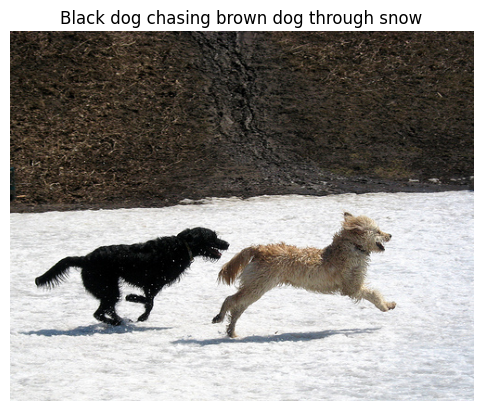

In [3]:
import matplotlib.pyplot as plt

example = ds["train"][0]

image = example["image"]
caption_1 = example["caption_1"] # 5 total captions

plt.imshow(image)
plt.axis("off")
plt.title(caption_1)
plt.show()

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.models as models
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet-50 Encoder

Remove last linear layer and replace with projection to input size of LSTM

In [7]:
# Load pretrained ResNet-50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Remove final classification layer
resnet50.fc = nn.Identity()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


# RNN Decoder

> A plain RNN won't work well so we use an LSTM for better sequential dependencies.

In [5]:
lstm = nn.LSTM(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, proj_size=0, device=None, dtype=None)

NameError: name 'input_size' is not defined

In [ ]:
self.encoder = resnet50

self.feature_proj = nn.Linear(
    2048,
    hidden_size
)

self.decoder =

In [74]:
class ImageEncoder(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()
    self.input_size = embed_dim

    # Load pretrained ResNet-50
    resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Remove final classification layer
    resnet50.fc = nn.Identity()

    self.encoder = resnet50

    self.feature_proj = nn.Linear(
        2048,
        embed_dim
    )
    for param in resnet50.parameters():
      param.requires_grad = False # Freeze params

  def forward(self, x):
    x = self.encoder(x)
    x = self.feature_proj(x)
    return x

In [75]:
class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # captions: (B, T)

        embeddings = self.embedding(captions[:, :-1])   # (B, T-1, embed_dim)

        # Use image feature as first input, then all but last embedded token
        inputs = torch.cat(
            [features.unsqueeze(1), embeddings[:, :-1, :]],
            dim=1
        )  # (B, T-1, embed_dim)

        outputs, _ = self.lstm(inputs)                  # (B, T-1, hidden_size)
        outputs = self.fc(outputs)                      # (B, T-1, vocab_size)

        return outputs

    def generate(self, features, start_idx, end_idx, max_len=20):
        generated = []

        # first input to LSTM is the image feature
        inputs = features.unsqueeze(1)   # (1, 1, embed_dim)
        hidden = None

        for _ in range(max_len):
            outputs, hidden = self.lstm(inputs, hidden)      # outputs: (1, 1, hidden_size)
            logits = self.fc(outputs[:, -1, :])              # (1, vocab_size)
            next_token = logits.argmax(dim=-1)               # (1,)

            token_id = next_token.item()
            if token_id == end_idx:
                break

            generated.append(token_id)

            # next input is embedding of predicted token
            inputs = self.embedding(next_token).unsqueeze(1) # (1, 1, embed_dim)

        return generated

## Transform Images to Tensors

In [76]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Build a Vocabulary

In [77]:
from collections import Counter
import re

def tokenize(text):
    text = text.lower().strip()
    return re.findall(r"\w+|[^\w\s]", text)

special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
caption_keys = [f'caption_{i}' for i in range(5)]

counter = Counter()

for ex in ds['train']:
    for key in caption_keys:
        counter.update(tokenize(ex[key]))

min_freq = 2
vocab_words = [word for word, freq in counter.items() if freq >= min_freq]

itos = special_tokens + sorted(vocab_words)
stoi = {word: i for i, word in enumerate(itos)}

PAD_IDX = stoi['<pad>']
START_IDX = stoi['<start>']
END_IDX = stoi['<end>']
UNK_IDX = stoi['<unk>']

vocab_size = len(itos)
print('vocab size:', vocab_size)

vocab size: 4460


## Numericalize Captions

In [78]:
def numericalize_caption(text, stoi, max_len=30):
    tokens = tokenize(text)
    ids = [stoi['<start>']]
    ids += [stoi.get(tok, stoi['<unk>']) for tok in tokens]
    ids += [stoi['<end>']]

    if len(ids) < max_len:
        ids += [stoi['<pad>']] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
        ids[-1] = stoi['<end>']

    return ids

## Dataset Wrapper

In [79]:
import random
import torch
from torch.utils.data import Dataset
from PIL import Image

class Flickr8kCaptionDataset(Dataset):
    def __init__(self, hf_split, stoi, image_transform, max_len=30, train=True):
        self.data = hf_split
        self.stoi = stoi
        self.image_transform = image_transform
        self.max_len = max_len
        self.train = train
        self.caption_keys = [f'caption_{i}' for i in range(5)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]

        image = ex['image']
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert('RGB')
        image = self.image_transform(image)

        if self.train:
            caption_key = random.choice(self.caption_keys)
        else:
            caption_key = 'caption_0'

        caption = ex[caption_key]
        caption_ids = numericalize_caption(caption, self.stoi, self.max_len)
        caption_ids = torch.tensor(caption_ids, dtype=torch.long)

        all_captions = [ex[k] for k in self.caption_keys]

        return {
            'image': image,
            'caption_ids': caption_ids,
            'raw_caption': caption,
            'all_captions': all_captions
        }

## Image Transform

In [80]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Create Dataloader

In [81]:
from torch.utils.data import DataLoader

train_ds = Flickr8kCaptionDataset(
    ds['train'],
    stoi,
    image_transform,
    max_len=30,
    train=True
)

val_ds = Flickr8kCaptionDataset(
    ds['validation'],
    stoi,
    image_transform,
    max_len=30,
    train=False
)

test_ds = Flickr8kCaptionDataset(
    ds['test'],
    stoi,
    image_transform,
    max_len=30,
    train=False
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

## Final Model

In [82]:
class ImageCaptioner(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=512):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim)
        self.decoder = CaptionDecoder(vocab_size, embed_dim, hidden_size)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

## Training Setup

In [83]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ImageCaptioner(
    vocab_size=vocab_size,
    embed_dim=256,
    hidden_size=512
).to(device)

for param in model.encoder.encoder.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [84]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        images = batch['image'].to(device)
        captions = batch['caption_ids'].to(device)

        optimizer.zero_grad()

        outputs = model(images, captions)      # (B, T-1, vocab_size)
        targets = captions[:, 1:]              # (B, T-1)

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            targets.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

## Evaluation

In [85]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        images = batch['image'].to(device)
        captions = batch['caption_ids'].to(device)

        outputs = model(images, captions)
        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            targets.reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / len(loader)

In [86]:
num_epochs = 25

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss:   {val_loss:.4f}')

Epoch 1/25
Train Loss: 5.7150
Val Loss:   4.7310
Epoch 2/25
Train Loss: 4.7421
Val Loss:   4.5461
Epoch 3/25
Train Loss: 4.5890
Val Loss:   4.4310
Epoch 4/25
Train Loss: 4.4914
Val Loss:   4.3468
Epoch 5/25
Train Loss: 4.4021
Val Loss:   4.2813
Epoch 6/25
Train Loss: 4.3463
Val Loss:   4.2243
Epoch 7/25
Train Loss: 4.3110
Val Loss:   4.1654
Epoch 8/25
Train Loss: 4.2264
Val Loss:   4.1141
Epoch 9/25
Train Loss: 4.1939
Val Loss:   4.0796
Epoch 10/25
Train Loss: 4.1501
Val Loss:   4.0411
Epoch 11/25
Train Loss: 4.0874
Val Loss:   4.0111
Epoch 12/25
Train Loss: 4.0532
Val Loss:   3.9781
Epoch 13/25
Train Loss: 4.0363
Val Loss:   3.9501
Epoch 14/25
Train Loss: 3.9946
Val Loss:   3.9252
Epoch 15/25
Train Loss: 3.9600
Val Loss:   3.8950
Epoch 16/25
Train Loss: 3.9435
Val Loss:   3.8730
Epoch 17/25
Train Loss: 3.9031
Val Loss:   3.8581
Epoch 18/25
Train Loss: 3.9016
Val Loss:   3.8376
Epoch 19/25
Train Loss: 3.8378
Val Loss:   3.8252
Epoch 20/25
Train Loss: 3.8227
Val Loss:   3.7989
Epoch 21/

## Caption Gen

In [87]:
def decode_tokens(token_ids, itos):
    words = []
    for idx in token_ids:
        token = itos[idx]
        if token in ['<start>', '<pad>']:
            continue
        if token == '<end>':
            break
        words.append(token)
    return ' '.join(words)

In [60]:
@torch.no_grad()
def generate_caption(model, image_tensor, stoi, itos, device, max_len=20):
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)
    features = model.encoder(image_tensor)

    token_ids = model.decoder.generate(
        features,
        start_idx=stoi['<start>'],
        end_idx=stoi['<end>'],
        max_len=max_len
    )

    return decode_tokens(token_ids, itos)

In [94]:
sample = val_ds[3]

pred = generate_caption(
    model,
    sample['image'],
    stoi,
    itos,
    device
)

print('Predicted:', pred)
print('References:')
for c in sample['all_captions']:
    print('-', c)

Predicted: two dogs in field
References:
- a big black dog jumps in the air to catch the tennis ball in his mouth .
- A dog looks at another dog catching a ball in the air
- A white dog is watching a black dog jump on a lawn next to a pile of large rocks .
- A white dog watching a black dog in the air .
- Two dogs playing with a tennis ball in the yard .


In [91]:
def show_image(img_tensor):
    """
    img_tensor: (3, 224, 224) normalized tensor
    """

    img = img_tensor.clone().cpu()

    # Unnormalize (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img * std + mean

    # Clamp to valid range
    img = img.clamp(0, 1)

    # Convert to HWC for plotting
    img = img.permute(1, 2, 0)

    plt.imshow(img)
    plt.axis("off")

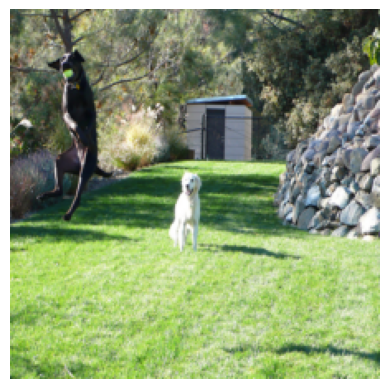

In [95]:
show_image(sample["image"])